#### feedback received

1. **resolution is 20m should be there: stac ko filter garera chai vayo openeo bata garne ma chai still need to check**
2. **scaling and offset should be checked**
3. **whittaker in fusets le hunxa ki yestai result ki nai hernu**
4. **aggregate deaked data after the whitatker**
5. Number of valid pixels before and after whittaker for each data that we have: k yo layer ya band banayera save garna milxa? (saving quality check layers or saving as seperate files and then compare or can it be saved within openEO as seperate file?)
6. plot per crop type instead of parcel so while saving would need to also consider saving the crop type information
8. outlier handling method within openEO?

### TODO:
- percentage/valid pixel count is that the way to do and how to plot and analyse that info
- final plotting of the results per crop type
- whittaker from fusets
- outlier handling within openEO

In [1]:
import openeo
# from fusets.openeo import load_whittakker_udf
# from fusets.openeo import whittaker_udf

connection = openeo.connect("openeo.terrascope.be").authenticate_oidc()

Authenticated using refresh token.


## Load Terrascope S2 BIOPAR FAPAR and LAI at 20m resolution

Required:
- Input data: Terrascope S2 BIOPAR LAI and FAPAR at 20m
- Spatial extent: NUTS3 region ‘Tongeren’, gpkg shared in mail thread
- Time window:
    - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
    - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)

In [2]:
import geopandas as gpd

Tongeren_polygon = gpd.read_file("NUTS3_Tongeren.gpkg")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")
# load to 4326
Tongeren_polygon = Tongeren_polygon.to_crs("EPSG:4326")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")


type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:3035
type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:4326


In [3]:
# feature collection from geopandas dataframe
import json
aoi = json.loads(Tongeren_polygon.to_json())

In [ ]:

test_date = ["2025-10-01", "2025-10-31"]

In [6]:
# lai
url = "https://stac.terrascope.be/collections/terrascope-s2-lai-v2"

## Filter FAPAR and LAI based on a parcel delineation map

More data on the gpkg in ticket and mail.

In [7]:
# load field from parcel delination
fields = gpd.read_file("AGRIPRC2025_Tongeren_selection.gpkg")
fields = fields.to_crs("EPSG:4326")
subset_fields = fields[:10]  # select first 5 fields for testing

In [8]:
# subset_fields

In [9]:
delineated_map = s2_fapar_scaled.filter_spatial(json.loads(subset_fields.to_json()))

In [10]:
without_smoothing = delineated_map.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job_nosmooth = without_smoothing.create_job(
    title="non-smoothed dekad aggregation",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job_nosmooth.start_and_wait()

0:00:00 Job 'j-26090512340548e392356f59a5a0ec8d': send 'start'
0:00:13 Job 'j-26090512340548e392356f59a5a0ec8d': queued (progress 0%)
0:00:18 Job 'j-26090512340548e392356f59a5a0ec8d': queued (progress 0%)
0:00:25 Job 'j-26090512340548e392356f59a5a0ec8d': queued (progress 0%)
0:00:33 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 3.5%)
0:00:43 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 5.0%)
0:00:55 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 6.8%)
0:01:11 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 9.0%)
0:01:30 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 11.6%)
0:01:54 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 14.6%)
0:02:24 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 18.1%)
0:03:01 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 22.1%)
0:03:48 Job 'j-26090512340548e392356f59a5a0ec8d': running (progress 26.6%)
0:04:47 Job 'j-26090512340548e392356f59a5a0ec8d': fin

<BatchJob job_id='j-26090512340548e392356f59a5a0ec8d'>

In [11]:
_= deked_job_nosmooth.download_results("new_udf/original_layers/")

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_24072\140198712.py:1: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  _= deked_job_nosmooth.download_results("new_udf/original_layers/")
c:\Users\SHARMAP\AppData\Local\miniconda3\envs\wo7\Lib\site-packages\openeo\rest\job.py:202: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
c:\Users\SHARMAP\AppData\Local\miniconda3\envs\wo7\Lib\site-packages\openeo\rest\job.py:206: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


I downloaded individual data for each parcels. Is it required as this or a full image with filtered values for the parcels?

## Run a Whittaker smoother for 2 scenarios:

- Pixel-based
- On Average FAPAR / LAI per parcel

The whittaker smoother requires a lambda parameter. Will need to follow up if it is whittaker service or a local implementation.

#### 1. pixel-based smoothening

In [12]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed = delineated_map.apply_dimension(
    process=openeo.UDF.from_file("whittaker_udf.py"),
    dimension="t",
    context={"smoothing_lambda":10000, "prediction_period": 2},
)

In [18]:
# Quality layers: count valid observations along time before and after smoothing.
# count_time() counts non-nodata values and preserves the spatial dimensions.
# delineated_map deaked aggregation not done yet
# smoothed whittaker smoothing done deaked aggregation not done yet
from openeo.processes import if_
valid_before = delineated_map.count_time().rename_labels("bands", ["valid_before"])
all_valid_before = delineated_map.apply(lambda x: if_(x.is_nodata(), 0, x))
total_before = all_valid_before.count_time().rename_labels("bands", ["total_before"])

valid_after = smoothed.count_time().rename_labels("bands", ["valid_after"])
all_valid_after = smoothed.apply(lambda x: if_(x.is_nodata(), 0, x))
total_after = all_valid_after.count_time().rename_labels("bands", ["total_after"])

In [14]:
# aggregate deaked after whittaker
smoothed_dekad = smoothed.aggregate_temporal_period(reducer="mean", period="dekad")
deked_job = smoothed_dekad.create_job(
    title="smoothed dekad aggregation",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
deked_job.start_and_wait()


0:00:00 Job 'j-2609051238554821a81b09b84894939a': send 'start'
0:00:14 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:00:19 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:00:26 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:00:34 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:00:44 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:00:56 Job 'j-2609051238554821a81b09b84894939a': queued (progress 0%)
0:01:11 Job 'j-2609051238554821a81b09b84894939a': running (progress 8.9%)
0:01:31 Job 'j-2609051238554821a81b09b84894939a': running (progress 11.5%)
0:01:55 Job 'j-2609051238554821a81b09b84894939a': running (progress 14.6%)
0:02:25 Job 'j-2609051238554821a81b09b84894939a': running (progress 18.1%)
0:03:02 Job 'j-2609051238554821a81b09b84894939a': running (progress 22.1%)
0:03:49 Job 'j-2609051238554821a81b09b84894939a': running (progress 26.5%)
0:04:48 Job 'j-2609051238554821a81b09b84894939a': running (pro

<BatchJob job_id='j-2609051238554821a81b09b84894939a'>

In [19]:
# quality_layers = valid_before.merge_cubes(valid_after)
quality_layers = valid_before.merge_cubes(valid_after).merge_cubes(total_before).merge_cubes(total_after)
quality_job = quality_layers.create_job(
    title="Quality Layers",
    sample_by_feature=True,
    feature_id_property="AGPAKEY",
    out_format="NetCDF"
)
quality_job.start_and_wait()

0:00:00 Job 'j-2609051258354f8bb6c0587bb54320b2': send 'start'
0:00:13 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:00:18 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:00:24 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:00:32 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:00:42 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:00:55 Job 'j-2609051258354f8bb6c0587bb54320b2': queued (progress 0%)
0:01:10 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 9.0%)
0:01:30 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 11.6%)
0:01:53 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 14.6%)
0:02:23 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 18.1%)
0:03:01 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 22.1%)
0:03:48 Job 'j-2609051258354f8bb6c0587bb54320b2': running (progress 26.5%)
0:04:46 Job 'j-2609051258354f8bb6c0587bb54320b2': running (pro

<BatchJob job_id='j-2609051258354f8bb6c0587bb54320b2'>

In [20]:
_ =deked_job.download_results("new_udf/data_layers/")

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_24072\1445223581.py:1: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  _ =deked_job.download_results("new_udf/data_layers/")
c:\Users\SHARMAP\AppData\Local\miniconda3\envs\wo7\Lib\site-packages\openeo\rest\job.py:202: UserDeprecationWarning: Call to deprecated method get_result. (Use `BatchJob.get_results` instead.) -- Deprecated since version 0.4.10.
  return self.get_result().download_files(target)
c:\Users\SHARMAP\AppData\Local\miniconda3\envs\wo7\Lib\site-packages\openeo\rest\job.py:206: UserDeprecationWarning: Call to deprecated class _Result. (Use `JobResults` instead) -- Deprecated since version 0.4.10.
  return _Result(self)


In [21]:
_= quality_job.download_results("new_udf/quality_layers/")

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_24072\3374208416.py:1: UserDeprecationWarning: Call to deprecated method download_results. (Instead use `BatchJob.get_results` and the more flexible download functionality of `JobResults`) -- Deprecated since version 0.4.10.
  _= quality_job.download_results("new_udf/quality_layers/")


In [19]:
# valid_before.execute_batch(title="Valid Observations Before Smoothing")

In [20]:
# valid_after.execute_batch(title="Valid Observations After Smoothing")

In [21]:
# # Replace nodata with zero so the denominator includes every temporal label.
# from openeo.processes import if_
# total_timesteps = (
#     delineated_map.apply(lambda x: if_(x.is_nodata(), 0, 1))
#     .count_time()
#     .rename_labels("bands", ["total_timesteps"])
# )

# valid_percentage_before = (valid_before / total_timesteps * 100).rename_labels(
#     "bands", ["valid_percentage_before"]
# )
# valid_percentage_after = (valid_after / total_timesteps * 100).rename_labels(
#     "bands", ["valid_percentage_after"]
# )

# # One output cube with two percentage bands. Save this separately from the
# # smoothed FAPAR cube, or export both bands together as one quality file.
# quality_layers = valid_percentage_before.merge_cubes(valid_percentage_after)

# quality_job = quality_layers.execute_batch(
#     title="FAPAR valid pixel percentage before and after Whittaker",
# )


In [22]:
# pixel_based_job = smoothed.create_job(
#     title="smoothed on delineated map", 
#     )
# pixel_based_job.start_and_wait()

In [23]:
# results = pixel_based_job.get_results()
# results.download_files("pixel_based/")

### plot pixel based analysis

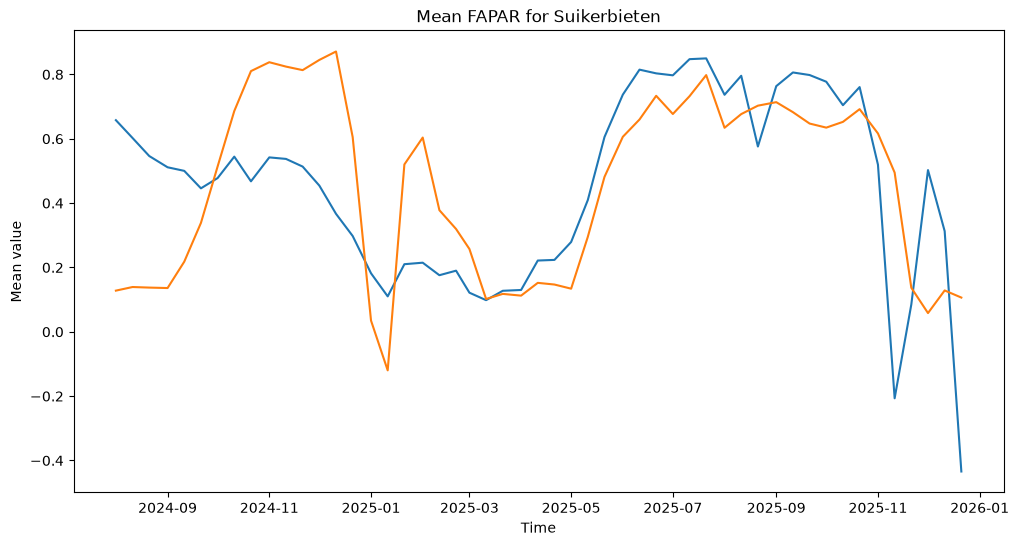

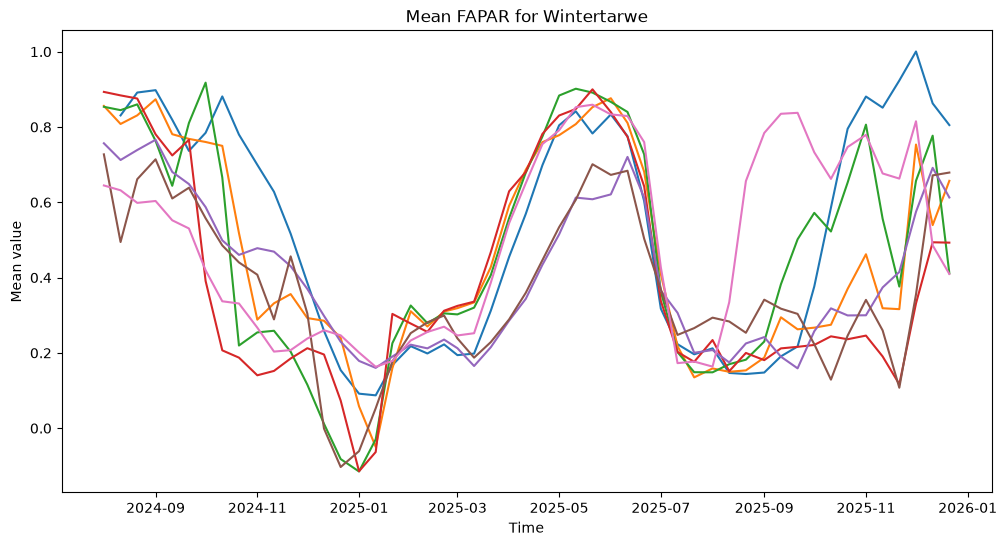

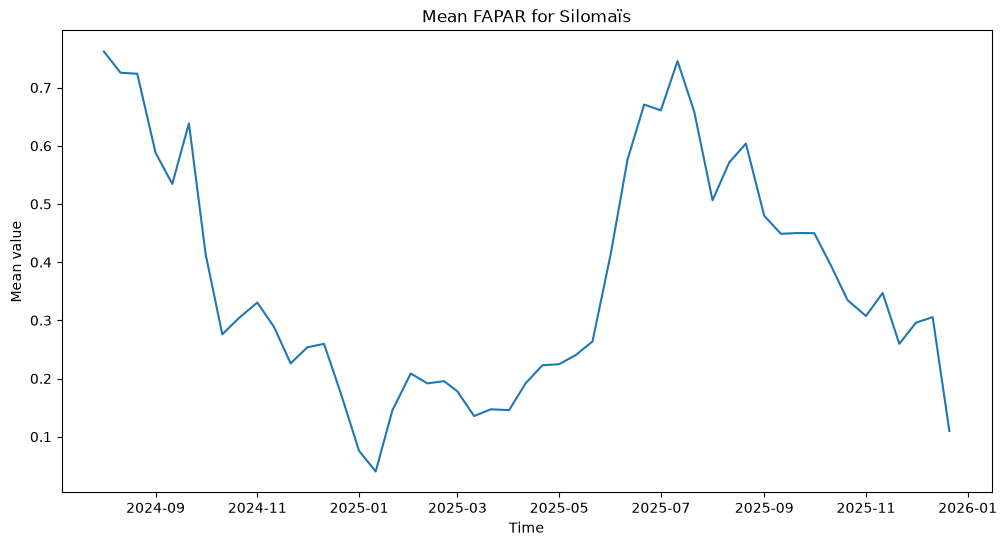

In [22]:
import xarray as xr
import matplotlib.pyplot as plt

data_folder = "new_udf/data_layers"
subset_data = subset_fields[['AGPAKEY','MAINCROP']]
for crop_type in subset_data['MAINCROP'].unique():
    crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
    #load netcdf data for each crop type
    fig, ax = plt.subplots(figsize=(12, 6))
    netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
    for agpakey, filepath in netcdf_data.items():

        # Open lazily — does not load the whole file into RAM
        ds = xr.open_dataset(filepath)

        # Spatial mean for every timestep
        ts = ds["FAPAR"].mean(dim=["x", "y"])

        # Load only the resulting time series
        ts = ts.load()

        # Plot
        ax.plot(
            ts["t"],
            ts,
            label=str(agpakey),
            # color='g'
        )

        ds.close()

    ax.set_xlabel("Time")
    ax.set_ylabel("Mean value")
    ax.set_title(f"Mean FAPAR for {crop_type}")
    plt.show()

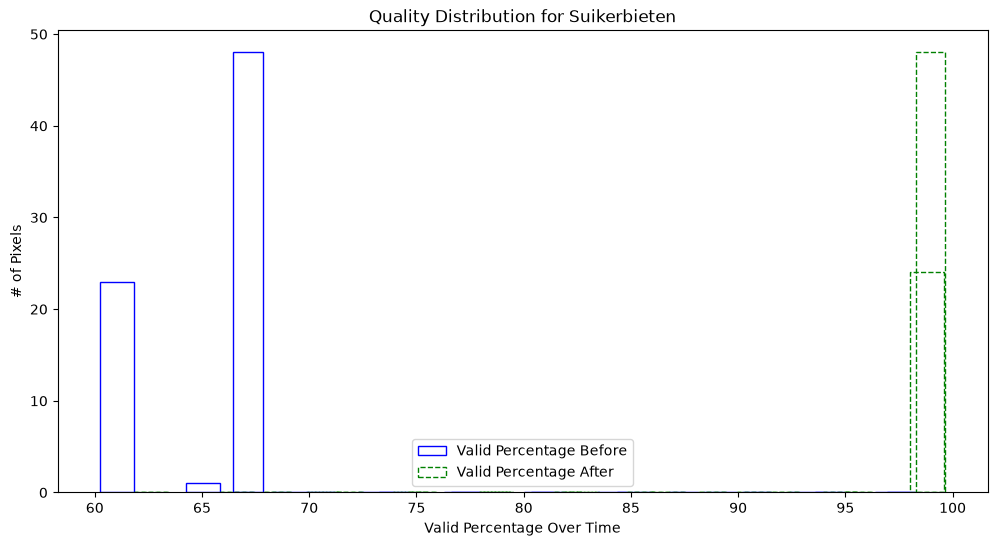

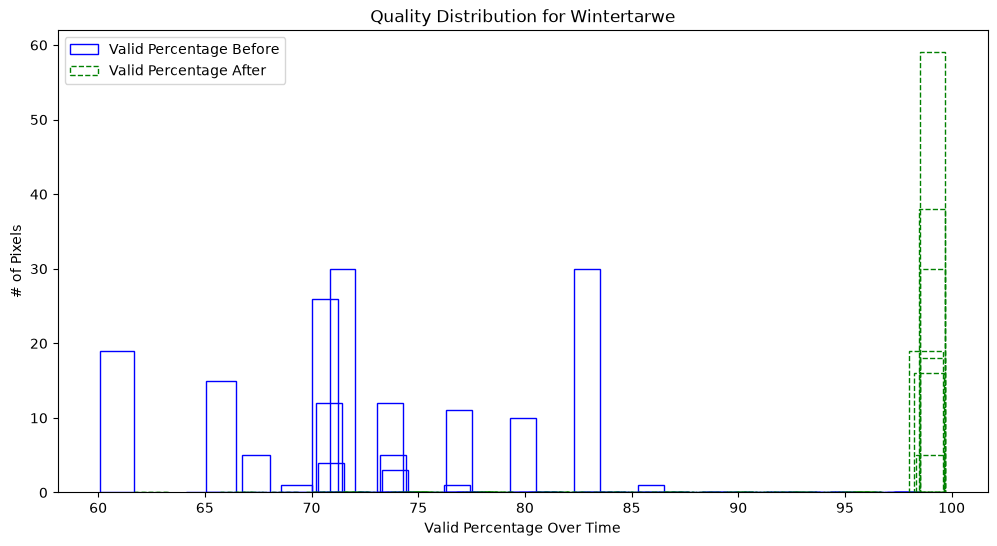

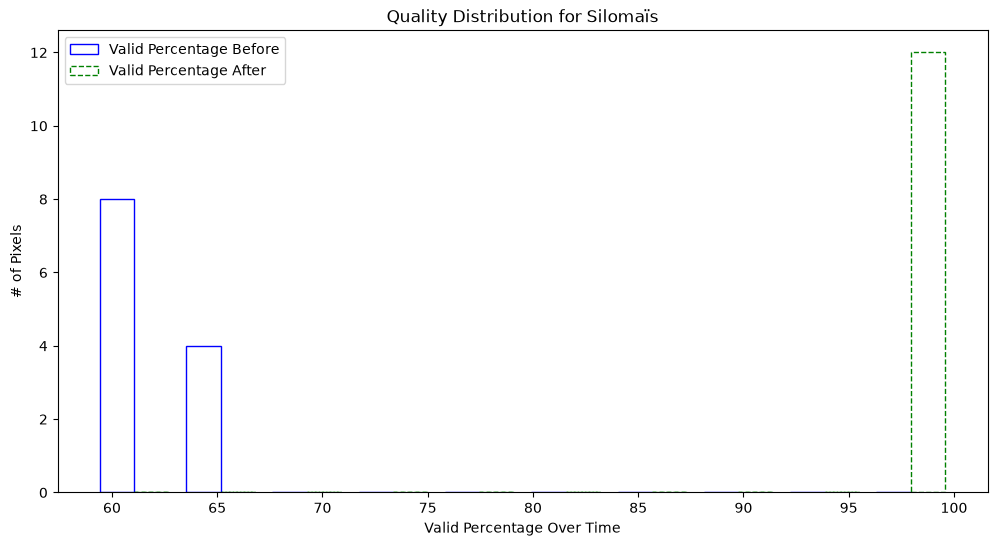

In [40]:
import xarray as xr
import matplotlib.pyplot as plt

data_folder = "new_udf/quality_layers"
subset_data = subset_fields[['AGPAKEY','MAINCROP']]

for crop_type in subset_data['MAINCROP'].unique():
    crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
    #load netcdf data for each crop type
    fig, ax = plt.subplots(figsize=(12, 6))
    netcdf_data = {row['AGPAKEY']: f"{data_folder}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
    for agpakey, filepath in netcdf_data.items():
        # Open lazily — does not load the whole file into RAM
        ds = xr.open_dataset(filepath)
        ds['valid_before_percentage'] = ds.valid_before / ds.total_before * 100
        ds['valid_after_percentage'] = ds.valid_after / ds.total_after * 100
        ds_valid = ds[['valid_before_percentage', 'valid_after_percentage']].where(ds[['valid_before_percentage', 'valid_after_percentage']] >= 0)
        plot_data = ds_valid[['valid_before_percentage', 'valid_after_percentage']].to_array().values.reshape(2,-1).swapaxes(0,1)
        
        linestyles = ['-', '--']
        edgecolors = ['b', 'g']
        labels = ['Valid Percentage Before', 'Valid Percentage After']
        ax.hist(plot_data, 
                fill=False, histtype='bar', linestyle=linestyles,
                edgecolor=edgecolors, label=labels)
        
        ds.close()

    ax.set_xlabel("Valid Percentage Over Time")
    ax.set_ylabel("# of Pixels")
    ax.legend( labels=labels)
    ax.set_title(f"Quality Distribution for {crop_type}")
    plt.show()

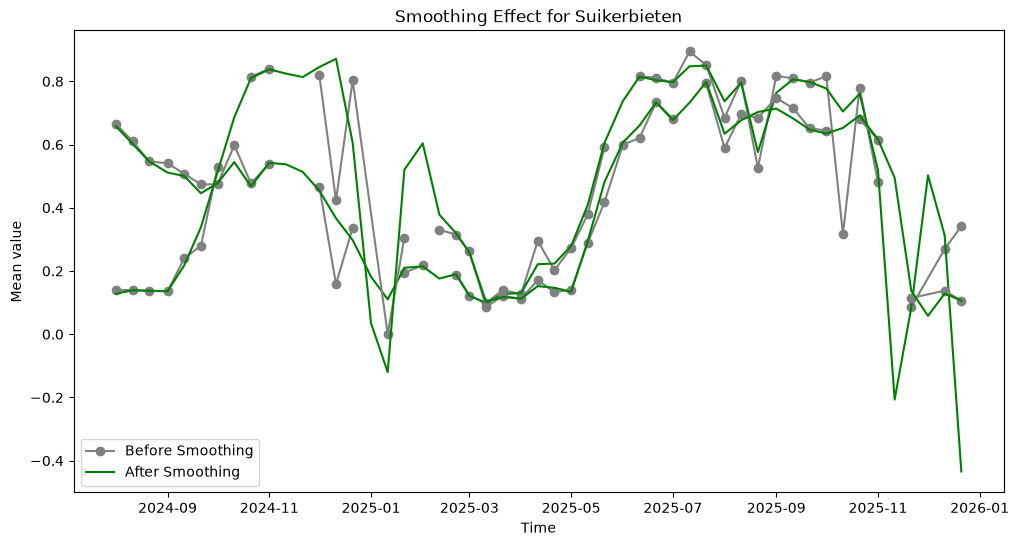

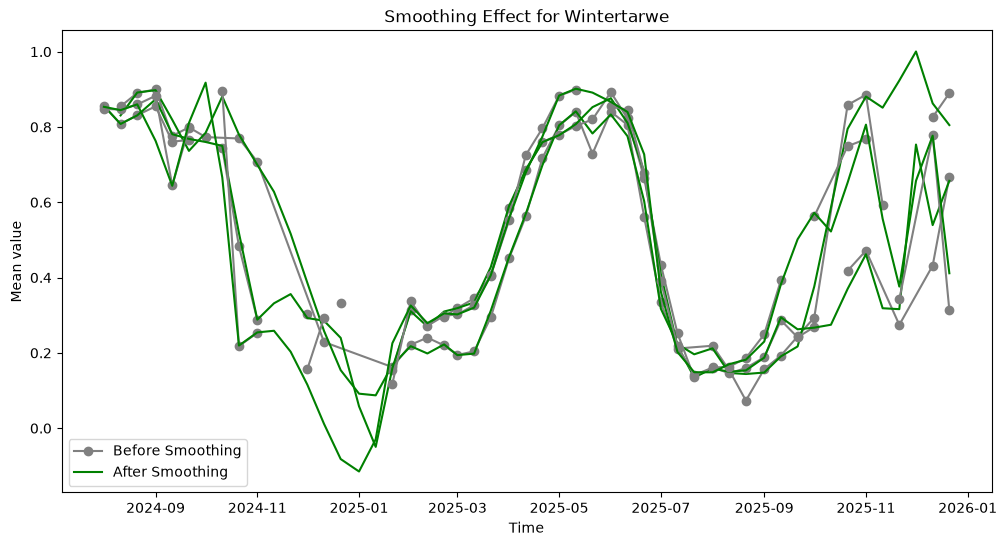

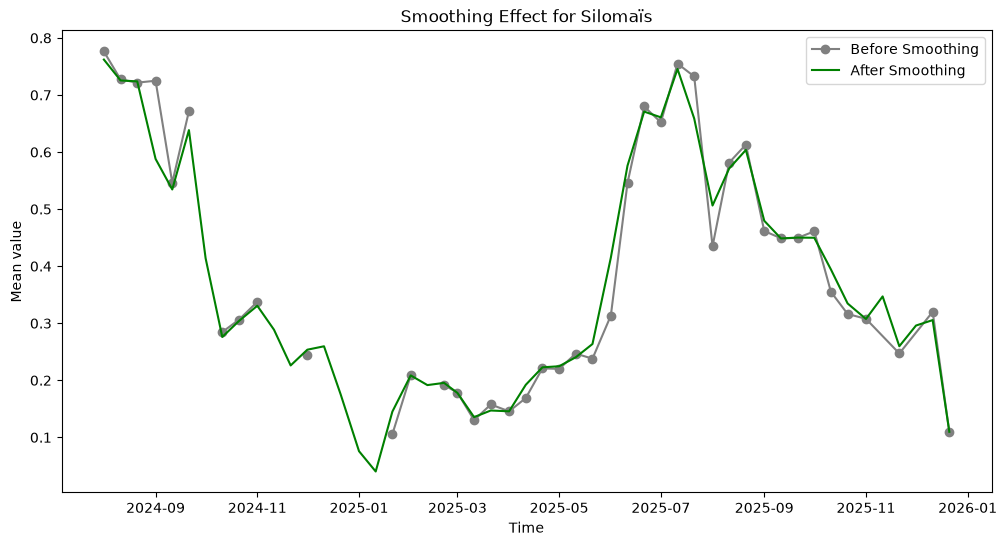

In [43]:
import xarray as xr
import matplotlib.pyplot as plt

post_data = "new_udf/data_layers"
pre_data = "new_udf/original_layers"
subset_data = subset_fields[['AGPAKEY','MAINCROP']]

for crop_type in subset_data['MAINCROP'].unique():
    crop_subset = subset_data[subset_data['MAINCROP'] == crop_type]
    #load netcdf data for each crop type
    fig, ax = plt.subplots(figsize=(12, 6))
    netcdf_data = {row['AGPAKEY']: f"{post_data}/openEO_{row['AGPAKEY']}.nc" for index, row in crop_subset.iterrows()}
    i=0
    for index, row in crop_subset.iterrows():

        # Open lazily — does not load the whole file into RAM
        agpakey = row['AGPAKEY']
        ds_pre = xr.open_dataset(f"{pre_data}/openEO_{agpakey}.nc")
        ds_post = xr.open_dataset(f"{post_data}/openEO_{agpakey}.nc")

        # Spatial mean for every timestep
        ts_pre = ds_pre["FAPAR"].mean(dim=["x", "y"])
        ts_post = ds_post["FAPAR"].mean(dim=["x", "y"])

        # Load only the resulting time series
        ts_pre = ts_pre.load()
        ts_post = ts_post.load()

        # Plot
        ax.plot(
            ts_pre["t"],
            ts_pre,
            label=f"{agpakey} (pre)",
            color='gray',
            marker='o', 
        )
        ax.plot(
            ts_post["t"],
            ts_post,
            label=f"{agpakey} (post)",
            color='green'
        )

        ds_pre.close()
        ds_post.close()
        # just plot one for diagnostic purposes
        # break
        i += 1
        if i >= 3:
            break

    ax.set_xlabel("Time")
    ax.set_ylabel("Mean value")
    ax.set_title(f"Smoothing Effect for {crop_type}")
    ax.legend(labels=['Before Smoothing', 'After Smoothing'])
    plt.show()

#### 2. Average FAPAR per parcel

In [ ]:
# fapar_timeseries_temporal = fapar_timeseries.process(
#     process_id="aggregate_temporal_period",
#     arguments={
#         "data": fapar_timeseries,
#         "period": "dekad",
#         "reducer": {
#             "process_graph": {
#                 "mean1": {
#                     "process_id": "mean",
#                     "arguments": {
#                         "data": {"from_parameter": "data"}
#                     },
#                     "result": True,
#                 }
#             }
#         },
#     },
# )
# fapar_timeseries_temporal.execute_batch()

In [48]:
# On Average FAPAR / LAI per parcel
fapar_timeseries = s2_fapar_scaled.aggregate_spatial(json.loads(subset_fields.to_json()), reducer="mean")
fapar_timeseries_smoothened = fapar_timeseries.run_udf(
        udf=openeo.UDF.from_file("whittaker_udf_ts.py"),
        runtime="Python",
        context={"smoothing_lambda": 10000, "prediction_period": 2},
)

In [46]:
timeseries_job = fapar_timeseries.execute_batch(
    title="fapar_timeseries for Tongeren",
    outputfile="fapar_timeseries_avg_b4smoothening_1yr.json")

Preflight process graph validation failed: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


0:00:00 Job 'j-2609051352334b6fb6d3f28ba89193b7': send 'start'
0:00:13 Job 'j-2609051352334b6fb6d3f28ba89193b7': queued (progress 0%)
0:00:19 Job 'j-2609051352334b6fb6d3f28ba89193b7': queued (progress 0%)
0:00:25 Job 'j-2609051352334b6fb6d3f28ba89193b7': queued (progress 0%)
0:00:33 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 3.5%)
0:00:43 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 5.0%)
0:00:56 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 6.8%)
0:01:11 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 9.0%)
0:01:30 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 11.6%)
0:01:54 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 14.6%)
0:02:24 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 18.1%)
0:03:02 Job 'j-2609051352334b6fb6d3f28ba89193b7': running (progress 22.1%)
0:03:49 Job 'j-2609051352334b6fb6d3f28ba89193b7': finished (progress 100%)


In [49]:
smoothed_timeseries_job = fapar_timeseries_smoothened.execute_batch(
    title="fapar_timeseries_smoothened for Tongeren",
    outputfile="fapar_timeseries_avg_after_smoothening_1yr.json")

0:00:00 Job 'j-2609051421584fcb897399d4642498f2': send 'start'
0:00:13 Job 'j-2609051421584fcb897399d4642498f2': created (progress 0%)
0:00:18 Job 'j-2609051421584fcb897399d4642498f2': queued (progress 0%)
0:00:25 Job 'j-2609051421584fcb897399d4642498f2': queued (progress 0%)
0:00:33 Job 'j-2609051421584fcb897399d4642498f2': queued (progress 0%)
0:00:43 Job 'j-2609051421584fcb897399d4642498f2': running (progress 4.9%)
0:00:55 Job 'j-2609051421584fcb897399d4642498f2': running (progress 6.7%)
0:01:10 Job 'j-2609051421584fcb897399d4642498f2': running (progress 8.9%)
0:01:30 Job 'j-2609051421584fcb897399d4642498f2': running (progress 11.5%)
0:01:54 Job 'j-2609051421584fcb897399d4642498f2': running (progress 14.6%)
0:02:24 Job 'j-2609051421584fcb897399d4642498f2': running (progress 18.1%)
0:03:01 Job 'j-2609051421584fcb897399d4642498f2': running (progress 22.1%)
0:03:48 Job 'j-2609051421584fcb897399d4642498f2': running (progress 26.5%)
0:04:47 Job 'j-2609051421584fcb897399d4642498f2': finis

C:\Users\SHARMAP\AppData\Local\Temp\ipykernel_24072\1413097340.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df.index.to_period("M").astype(str)


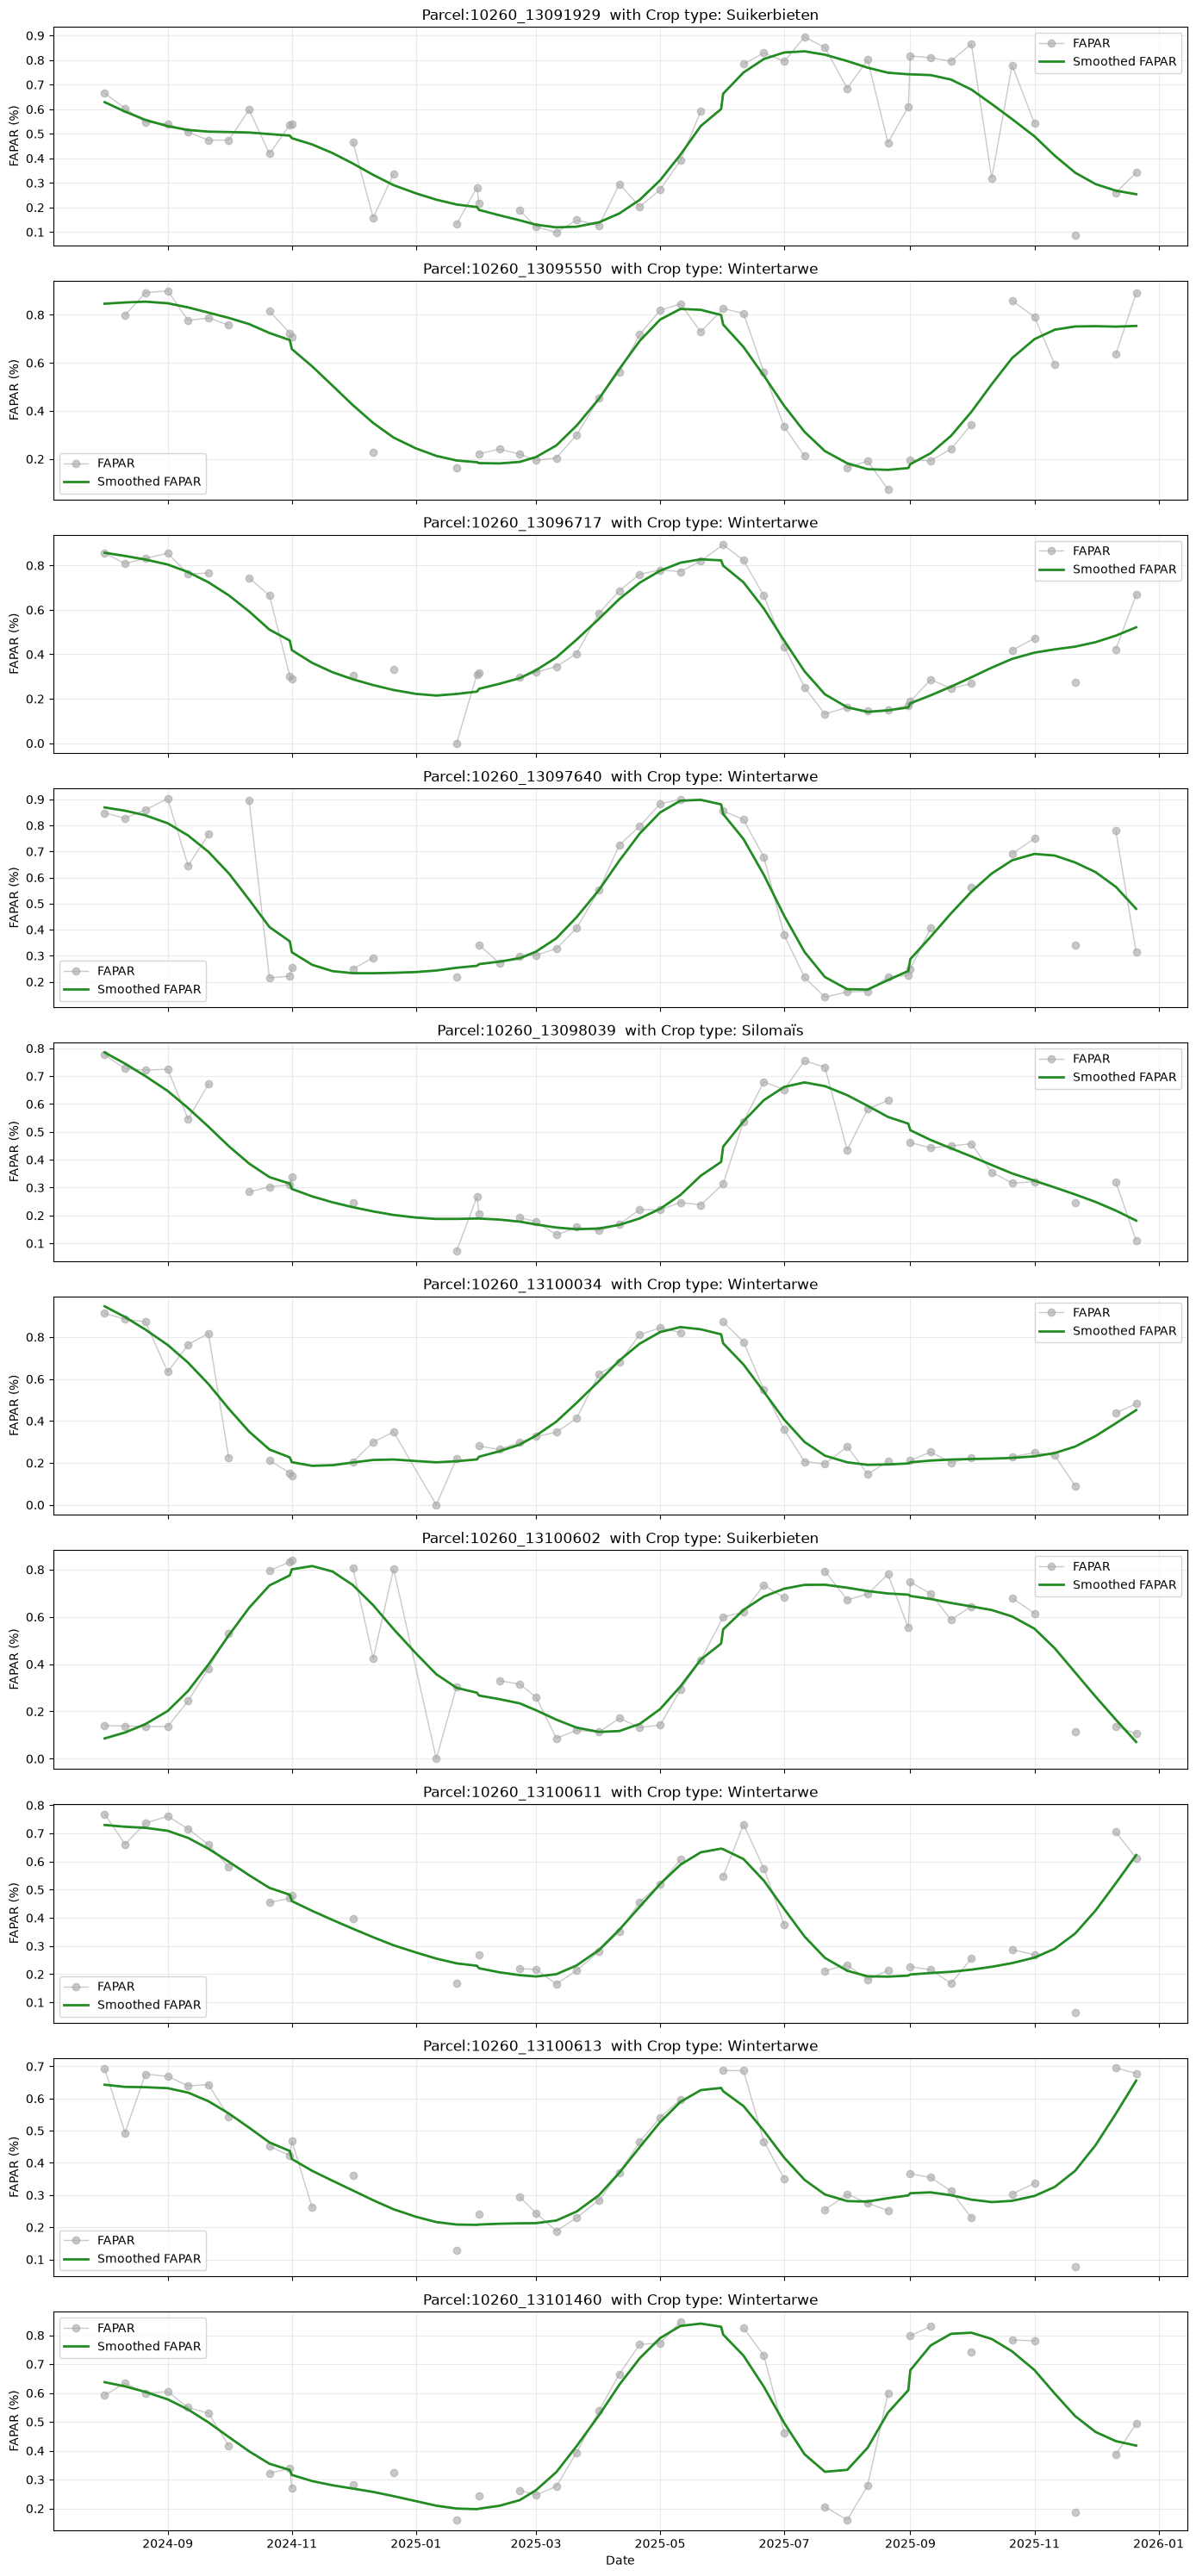

In [66]:
import json
import matplotlib.pyplot as plt
import pandas as pd
def convert_to_dekad(df):
    dekad_index = (
        df.index.to_period("M").astype(str)
        + "-"
        + (((df.index.day - 1) // 10) * 10 + 1).astype(str)
    )

    df_dekad = df.groupby(dekad_index).mean()

    df_dekad.index = pd.to_datetime(df_dekad.index)
    return df_dekad.sort_index()

# raw output: {date: [[value_polygon_0], [value_polygon_1], ...]}
with open("fapar_timeseries_avg_b4smoothening_1yr.json") as f:
    raw_data = json.load(f)

n_polygons = len(next(iter(raw_data.values())))
raw_fapar = pd.DataFrame(
    {f"polygon_{i}": {date: values[i][0] for date, values in raw_data.items()} for i in range(n_polygons)}
)
raw_fapar.index = pd.to_datetime(raw_fapar.index)
raw_fapar = raw_fapar.sort_index()

# smoothed output: {"variable_0_polygon_N": {date: value}}
with open("fapar_timeseries_avg_after_smoothening_1yr.json") as f:
    smoothed_data = json.load(f)

smoothed_fapar = pd.DataFrame(
    {key.replace("variable_0_", ""): pd.Series(values) for key, values in smoothed_data.items()}
)
smoothed_fapar.index = pd.to_datetime(smoothed_fapar.index)
smoothed_fapar = smoothed_fapar.sort_index()

# rename column names to AGPAKEY values for better readability
updated_columns = {f"polygon_{i}": agpakey for i, agpakey in enumerate(subset_data.AGPAKEY.tolist())}
raw_fapar.rename(columns=updated_columns, inplace=True)
smoothed_fapar.rename(columns=updated_columns, inplace=True)

raw_fapar_dekad = convert_to_dekad(raw_fapar)
smoothed_fapar_dekad = convert_to_dekad(smoothed_fapar)

fig, axes = plt.subplots(n_polygons, 1, figsize=(14, 3 * n_polygons), sharex=True)
for i, ax in enumerate(axes):
    col = subset_data.AGPAKEY.tolist()[i]
    crop_type = subset_data.MAINCROP.tolist()[i]
    ax.plot(raw_fapar_dekad.index, raw_fapar_dekad[col], color="0.65", marker="o", linewidth=1, alpha=0.6, label="FAPAR")
    if col in smoothed_fapar_dekad.columns:
        ax.plot(smoothed_fapar_dekad.index, smoothed_fapar_dekad[col], color="forestgreen", linewidth=2, label="Smoothed FAPAR")
    ax.set_title(f"Parcel:{col}  with Crop type: {crop_type}")
    ax.set_ylabel("FAPAR (%)")
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()